In [1]:
# Configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path

plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'fm_prelim'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling
Output directory: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim


In [2]:
# Import custom modules
from modules.finance.models.arx import (
    LagSpec, 
    automl_group_arx, 
    make_group_arx_supervised,
    INDEX_FAMILIES
)
from modules.finance.evaluation.metrics import (
    compute_all_metrics,
    bootstrap_coefficient_ci,
    diebold_mariano_test,
    permutation_importance_cv,
    get_significance_stars
)
from modules.finance.visualisation.feature_importance import (
    plot_coefficient_importance,
    plot_model_comparison_bars
)

print("Modules imported successfully")
print(f"\nEmotion index families: {list(INDEX_FAMILIES.keys())}")

Modules imported successfully

Emotion index families: ['ei', 'epi', 'epi_signed', 'ccd', 'intensity', 'surprise', 'split']


## Load Data

Load financial returns and emotion indices. The emotion indices include all 7 families with 4 weighting variants each.

In [3]:
# Load financial data
df = pd.read_csv(DATA_DIR / 'financial_returns_and_controls.csv', index_col=0, parse_dates=True)
df = df.sort_index()

# Load emotion data from epi_data.json
import json
with open(DATA_DIR / 'epi_data.json', 'r') as f:
    epi_data = json.load(f)

epi_df = pd.DataFrame(epi_data)
epi_df['date'] = pd.to_datetime(epi_df['date'])
epi_df = epi_df.set_index('date').sort_index()

print(f"Financial data shape: {df.shape}")
print(f"Emotion data shape: {epi_df.shape}")

# Join emotion data with financial data
df = df.join(epi_df, how='left')
print(f"Joined data shape: {df.shape}")

# Define columns
TARGET_COLS = ['r_btc', 'r_gold', 'r_spx']
CONTROL_COLS = ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']

# Forward fill controls
for col in CONTROL_COLS:
    if col in df.columns:
        df[col] = df[col].ffill()

# Identify emotion index columns (from epi_df)
emotion_cols = ['epi_signed_topicweighted']
print(f"\nDate range: {df.index.min()} to {df.index.max()}")
print(f"\nTarget columns: {TARGET_COLS}")
print(f"Control columns: {CONTROL_COLS}")
print(f"Emotion index columns: {len(emotion_cols)}")
print(f"\nEmotion columns: {emotion_cols}")

Financial data shape: (104, 19)
Emotion data shape: (148, 27)
Joined data shape: (104, 46)

Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00

Target columns: ['r_btc', 'r_gold', 'r_spx']
Control columns: ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']
Emotion index columns: 1

Emotion columns: ['epi_signed_topicweighted']


In [4]:
# Prepare clean dataset
df_clean = df.dropna(subset=TARGET_COLS)

# Fill emotion columns with 0 if missing
for col in emotion_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

print(f"Clean data shape: {df_clean.shape}")
print(f"\nMissing values in emotion columns: {df_clean[emotion_cols].isna().sum().sum()}")

Clean data shape: (104, 46)

Missing values in emotion columns: 0


## Emotion-Enhanced ARX Configuration

Configure the model with heterogeneous lags for each emotion index family.

In [5]:
# Emotion-enhanced configuration
EMOTION_CONFIG = {
    # AR and control lag ranges
    'p_range': (1, 5),
    'q_controls_range': (0, 3),
    
    # Per-family emotion index lag ranges
    'q_ei_range': (0, 5),
    'q_epi_range': (0, 5),
    'q_epi_signed_range': (0, 5),
    'q_ccd_range': (0, 5),
    'q_intensity_range': (0, 5),
    'q_surprise_range': (0, 5),
    'q_split_range': (0, 5),
    
    # No cross-asset (univariate)
    'q_cross_range': (0, 0),
    
    # Optimization settings
    'n_trials': 300,
    'initial_train_size': 60,
    'step_size': 1,
    'test_size': 1,
}

print("Emotion-Enhanced ARX Configuration:")
for key, value in EMOTION_CONFIG.items():
    print(f"  {key}: {value}")

Emotion-Enhanced ARX Configuration:
  p_range: (1, 5)
  q_controls_range: (0, 3)
  q_ei_range: (0, 5)
  q_epi_range: (0, 5)
  q_epi_signed_range: (0, 5)
  q_ccd_range: (0, 5)
  q_intensity_range: (0, 5)
  q_surprise_range: (0, 5)
  q_split_range: (0, 5)
  q_cross_range: (0, 0)
  n_trials: 300
  initial_train_size: 60
  step_size: 1
  test_size: 1


## Train Emotion-Enhanced Models

Train ARX models with emotion indices for each asset using Optuna optimization.

In [6]:
# Prepare emotion index DataFrame
social_df = df_clean[emotion_cols] if emotion_cols else None
controls_df = df_clean[CONTROL_COLS].fillna(0)

# Store results
emotion_results = {}

for target in TARGET_COLS:
    print(f"\n{'='*60}")
    print(f"Training emotion-enhanced ARX for {target}")
    print('='*60)
    
    y = df_clean[target]  # Keep as Series
    
    # Run automl optimization
    result = automl_group_arx(
        y=y,
        social=social_df,
        controls=controls_df,
        cross=None,
        p_range=EMOTION_CONFIG['p_range'],
        q_controls_range=EMOTION_CONFIG['q_controls_range'],
        q_ei_range=EMOTION_CONFIG['q_ei_range'],
        q_epi_range=EMOTION_CONFIG['q_epi_range'],
        q_epi_signed_range=EMOTION_CONFIG['q_epi_signed_range'],
        q_ccd_range=EMOTION_CONFIG['q_ccd_range'],
        q_intensity_range=EMOTION_CONFIG['q_intensity_range'],
        q_surprise_range=EMOTION_CONFIG['q_surprise_range'],
        q_split_range=EMOTION_CONFIG['q_split_range'],
        n_trials=EMOTION_CONFIG['n_trials'],
        initial_train_size=EMOTION_CONFIG['initial_train_size'],
        step_size=EMOTION_CONFIG['step_size'],
        test_size=EMOTION_CONFIG['test_size'],
    )
    
    emotion_results[target] = result
    
    print(f"\nBest specification for {target}:")
    print(f"  AR lags (p): {result['best_lags'].ar_p}")
    print(f"  Control lags: {result['best_lags'].q_controls}")
    print(f"  EI lags: {result['best_lags'].q_ei}")
    print(f"  EPI lags: {result['best_lags'].q_epi}")
    print(f"  EPI_Signed lags: {result['best_lags'].q_epi_signed}")
    print(f"  CCD lags: {result['best_lags'].q_ccd}")
    print(f"  Intensity lags: {result['best_lags'].q_intensity}")
    print(f"  Surprise lags: {result['best_lags'].q_surprise}")
    print(f"  Split lags: {result['best_lags'].q_split}")
    print(f"  CV MAE: {result['best_score_mae']:.6f}")
    print(f"  CV RMSE: {result['best_score_rmse']:.6f}")

[I 2026-01-24 16:48:24,531] A new study created in memory with name: no-name-9bb73ab2-8f7f-41a0-9108-851096eb8cdf



Training emotion-enhanced ARX for r_btc

Best specification for r_btc:
  AR lags (p): 5
  Control lags: 2
  EI lags: 5
  EPI lags: 4
  EPI_Signed lags: 4
  CCD lags: 2
  Intensity lags: 2
  Surprise lags: 1
  Split lags: 0
  CV MAE: 0.015191
  CV RMSE: 0.015191

Training emotion-enhanced ARX for r_gold

Best specification for r_gold:
  AR lags (p): 2
  Control lags: 1
  EI lags: 4
  EPI lags: 5
  EPI_Signed lags: 3
  CCD lags: 0
  Intensity lags: 3
  Surprise lags: 2
  Split lags: 5
  CV MAE: 0.008487
  CV RMSE: 0.008487

Training emotion-enhanced ARX for r_spx

Best specification for r_spx:
  AR lags (p): 3
  Control lags: 1
  EI lags: 5
  EPI lags: 2
  EPI_Signed lags: 0
  CCD lags: 3
  Intensity lags: 1
  Surprise lags: 1
  Split lags: 5
  CV MAE: 0.010048
  CV RMSE: 0.010048


In [7]:
# Summary of optimal lag specifications
print("\n" + "="*60)
print("OPTIMAL LAG SPECIFICATION SUMMARY")
print("="*60)

spec_data = []
for target, results in emotion_results.items():
    spec = results['best_lags']
    spec_data.append({
        'Asset': target,
        'p': spec.ar_p,
        'q_control': spec.q_controls,
        'q_ei': spec.q_ei,
        'q_epi': spec.q_epi,
        'q_epi_signed': spec.q_epi_signed,
        'q_ccd': spec.q_ccd,
        'q_intensity': spec.q_intensity,
        'q_surprise': spec.q_surprise,
        'q_split': spec.q_split,
        'CV MAE': results['best_score_mae'],
        'CV RMSE': results['best_score_rmse'],
    })

spec_df = pd.DataFrame(spec_data)
display(spec_df)


OPTIMAL LAG SPECIFICATION SUMMARY


,Asset,p,q_control,q_ei,q_epi,q_epi_signed,q_ccd,q_intensity,q_surprise,q_split,CV MAE,CV RMSE
0,r_btc,5,2,5,4,4,2,2,1,0,0.015191,0.015191
1,r_gold,2,1,4,5,3,0,3,2,5,0.008487,0.008487
2,r_spx,3,1,5,2,0,3,1,1,5,0.010048,0.010048


## Out-of-Sample Evaluation

In [8]:
# Generate OOS predictions
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet

oos_predictions = {}
oos_metrics = {}

for target in TARGET_COLS:
    print(f"\nGenerating OOS predictions for {target}...")
    
    spec = emotion_results[target]['best_lags']
    best_params = emotion_results[target]['best_model_params']
    model_family = emotion_results[target]['best_model_family']
    y = df_clean[target]  # Keep as Series
    
    # Build design matrix
    X_design, y_design = make_group_arx_supervised(
        y=y,
        social=social_df,
        controls=controls_df,
        cross=None,
        lags=spec,
    )
    
    # Rolling window predictions
    y_true_list = []
    y_pred_list = []
    dates_list = []
    
    initial_train = EMOTION_CONFIG['initial_train_size']
    step_size = EMOTION_CONFIG['step_size']
    test_size = EMOTION_CONFIG['test_size']
    n_samples = len(y_design)
    
    for train_end in range(initial_train, n_samples - test_size + 1, step_size):
        test_start = train_end
        test_end = test_start + test_size
        
        X_train = X_design.iloc[:train_end]
        y_train = y_design.iloc[:train_end]
        X_test = X_design.iloc[test_start:test_end]
        y_test = y_design.iloc[test_start:test_end]
        
        # Build model with best params
        if model_family == "ridge":
            model = Ridge(**best_params, random_state=42)
        else:
            model = ElasticNet(**best_params, random_state=42, max_iter=20000)
        
        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        
        y_true_list.extend(y_test.values)
        y_pred_list.extend(y_pred)
        dates_list.extend(y_test.index.tolist())
    
    oos_predictions[target] = pd.DataFrame({
        'date': dates_list,
        'y_true': y_true_list,
        'y_pred': y_pred_list
    }).set_index('date')
    
    oos_metrics[target] = compute_all_metrics(
        np.array(y_true_list), 
        np.array(y_pred_list)
    )
    
    print(f"  OOS MAE: {oos_metrics[target]['mae']:.6f}")
    print(f"  OOS RMSE: {oos_metrics[target]['rmse']:.6f}")


Generating OOS predictions for r_btc...
  OOS MAE: 0.015191
  OOS RMSE: 0.019625

Generating OOS predictions for r_gold...
  OOS MAE: 0.008487
  OOS RMSE: 0.011268

Generating OOS predictions for r_spx...
  OOS MAE: 0.010048
  OOS RMSE: 0.015808


## Compare with Baseline

Compare emotion-enhanced models with baseline using Diebold-Mariano test.

In [9]:
# Load baseline results
baseline_metrics_path = OUTPUT_DIR / 'arx_baseline_metrics.csv'

if baseline_metrics_path.exists():
    baseline_df = pd.read_csv(baseline_metrics_path)
    
    print("Model Comparison: Baseline vs Emotion-Enhanced ARX")
    print("="*70)
    
    comparison_data = []
    dm_results = {}
    
    for target in TARGET_COLS:
        baseline_row = baseline_df[baseline_df['asset'] == target].iloc[0]
        emotion_metrics = oos_metrics[target]
        
        # Load baseline predictions for DM test
        baseline_pred_path = OUTPUT_DIR / f'arx_baseline_predictions_{target}.csv'
        if baseline_pred_path.exists():
            baseline_preds = pd.read_csv(baseline_pred_path, index_col='date', parse_dates=True)
            emotion_preds = oos_predictions[target]
            
            common_dates = baseline_preds.index.intersection(emotion_preds.index)
            baseline_aligned = baseline_preds.loc[common_dates]
            emotion_aligned = emotion_preds.loc[common_dates]
            
            # Compute forecast errors
            e1 = baseline_aligned['y_true'].values - baseline_aligned['y_pred'].values  # Baseline errors
            e2 = emotion_aligned['y_true'].values - emotion_aligned['y_pred'].values    # Emotion errors
            
            dm_result = diebold_mariano_test(e1, e2, h=1, loss_function='SE')
            dm_results[target] = {'statistic': dm_result['statistic'], 'p_value': dm_result['pvalue']}
        else:
            dm_results[target] = {'statistic': None, 'p_value': None}
        
        # Calculate improvement
        mae_improvement = (baseline_row['oos_mae'] - emotion_metrics['mae']) / baseline_row['oos_mae'] * 100
        rmse_improvement = (baseline_row['oos_rmse'] - emotion_metrics['rmse']) / baseline_row['oos_rmse'] * 100
        
        comparison_data.append({
            'Asset': target,
            'Baseline MAE': baseline_row['oos_mae'],
            'Emotion MAE': emotion_metrics['mae'],
            'MAE Δ%': mae_improvement,
            'Baseline RMSE': baseline_row['oos_rmse'],
            'Emotion RMSE': emotion_metrics['rmse'],
            'RMSE Δ%': rmse_improvement,
            'DM p-value': dm_results[target]['p_value'],
            'Significance': get_significance_stars(dm_results[target]['p_value']) if dm_results[target]['p_value'] else ''
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df.style.format({
        'Baseline MAE': '{:.6f}', 'Emotion MAE': '{:.6f}', 'MAE Δ%': '{:+.2f}',
        'Baseline RMSE': '{:.6f}', 'Emotion RMSE': '{:.6f}', 'RMSE Δ%': '{:+.2f}',
        'DM p-value': '{:.4f}'
    }))
    
    print("\nNote: Positive Δ% indicates improvement. *** p<0.01, ** p<0.05, * p<0.10")
else:
    print("Baseline results not found. Run 410_fm_baseline_arx.ipynb first.")

Model Comparison: Baseline vs Emotion-Enhanced ARX


,Asset,Baseline MAE,Emotion MAE,MAE Δ%,Baseline RMSE,Emotion RMSE,RMSE Δ%,DM p-value,Significance
0,r_btc,0.015244,0.015191,+0.35,0.019569,0.019625,-0.28,0.9584,
1,r_gold,0.009057,0.008487,+6.30,0.011993,0.011268,+6.05,0.3443,
2,r_spx,0.009901,0.010048,-1.48,0.015690,0.015808,-0.75,0.7214,



Note: Positive Δ% indicates improvement. *** p<0.01, ** p<0.05, * p<0.10


## Feature Importance Analysis

Analyze feature importance using multiple methods:
1. ElasticNet coefficients
2. Permutation importance
3. SHAP values

In [10]:
# Generate feature names for the design matrix
def get_emotion_feature_names(spec, control_cols, emotion_cols):
    """Generate feature names for emotion-enhanced ARX model."""
    from modules.finance.models.arx import _classify_social_columns, INDEX_FAMILIES
    
    names = []
    # AR lags
    for lag in range(1, spec.p + 1):
        names.append(f'AR_lag{lag}')
    
    # Control lags
    for lag in range(spec.q_control + 1):
        for col in control_cols:
            if lag == 0:
                names.append(col)
            else:
                names.append(f'{col}_lag{lag}')
    
    # Emotion index lags (per family)
    family_lags = {
        'ei': spec.q_ei, 'epi': spec.q_epi, 'epi_signed': spec.q_epi_signed,
        'ccd': spec.q_ccd, 'intensity': spec.q_intensity, 
        'surprise': spec.q_surprise, 'split': spec.q_split
    }
    
    family_map = _classify_social_columns(emotion_cols)
    
    for family, cols in family_map.items():
        q = family_lags.get(family, 0)
        for lag in range(q + 1):
            for col in cols:
                if lag == 0:
                    names.append(col)
                else:
                    names.append(f'{col}_lag{lag}')
    
    return names

print("Feature name generator ready.")

Feature name generator ready.


In [11]:
# 1. ElasticNet Coefficient Analysis with Bootstrap CIs
print("="*60)
print("COEFFICIENT ANALYSIS WITH BOOTSTRAP CONFIDENCE INTERVALS")
print("="*60)

bootstrap_results = {}

for target in TARGET_COLS:
    print(f"\nBootstrap analysis for {target}...")
    
    spec = emotion_results[target]['best_lags']
    y = df_clean[target]  # Keep as Series
    
    X_design, y_design = make_group_arx_supervised(
        y=y,
        social=social_df,
        controls=controls_df,
        cross=None,
        lags=spec,
    )
    
    feature_names = list(X_design.columns)
    
    # Get the fitted pipeline
    fitted_pipeline = emotion_results[target]['fitted_pipeline']
    
    ci_results = bootstrap_coefficient_ci(
        X_design.values, 
        y_design.values,
        pipeline=fitted_pipeline,
        feature_names=feature_names,
        n_iter=1000,
        alpha_levels=[0.01, 0.05, 0.10],
    )
    
    bootstrap_results[target] = ci_results
    
    # Count significant features
    sig_01 = (ci_results['sig_99'] == True).sum() if 'sig_99' in ci_results.columns else 0
    sig_05 = (ci_results['sig_95'] == True).sum() if 'sig_95' in ci_results.columns else 0
    sig_10 = (ci_results['sig_90'] == True).sum() if 'sig_90' in ci_results.columns else 0
    
    print(f"  Significant features: {sig_01} (1%), {sig_05} (5%), {sig_10} (10%)")

COEFFICIENT ANALYSIS WITH BOOTSTRAP CONFIDENCE INTERVALS

Bootstrap analysis for r_btc...
  Significant features: 0 (1%), 0 (5%), 0 (10%)

Bootstrap analysis for r_gold...
  Significant features: 0 (1%), 2 (5%), 4 (10%)

Bootstrap analysis for r_spx...
  Significant features: 0 (1%), 0 (5%), 0 (10%)


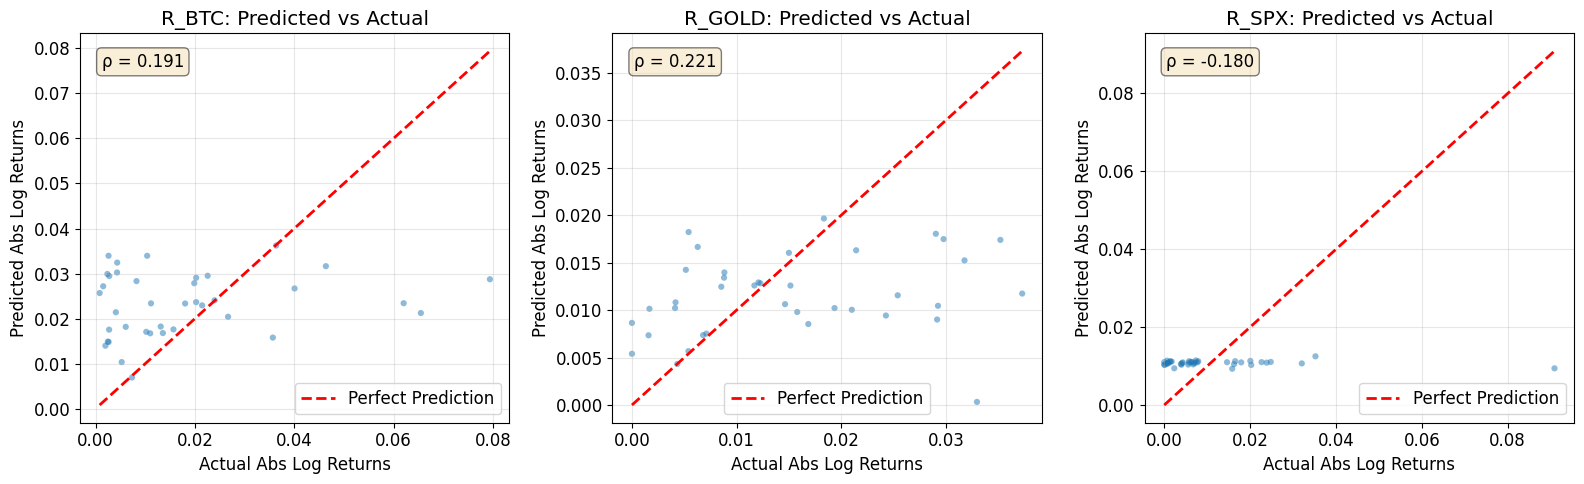


Correlation between predicted and actual:
  r_btc: 0.1910
  r_gold: 0.2212
  r_spx: -0.1804


In [12]:
# Plot predicted vs actual absolute log returns
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    preds_df = oos_predictions[target]
    
    # Scatter plot
    ax.scatter(preds_df['y_true'], preds_df['y_pred'], alpha=0.5, s=20, edgecolors='none')
    
    # Perfect prediction line
    min_val = min(preds_df['y_true'].min(), preds_df['y_pred'].min())
    max_val = max(preds_df['y_true'].max(), preds_df['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Labels and title
    ax.set_xlabel('Actual Abs Log Returns')
    ax.set_ylabel('Predicted Abs Log Returns')
    ax.set_title(f'{target.upper()}: Predicted vs Actual')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    ax.text(0.05, 0.95, f'ρ = {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_baseline_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation between predicted and actual:")
for target in TARGET_COLS:
    preds_df = oos_predictions[target]
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    print(f"  {target}: {corr:.4f}")

In [13]:
# Display top significant emotion features
print("\n" + "="*60)
print("TOP SIGNIFICANT EMOTION FEATURES (α = 0.05)")
print("="*60)

for target in TARGET_COLS:
    print(f"\n{target}:")
    results_df = bootstrap_results[target].reset_index()  # Reset index to get feature as column
    
    # Filter emotion features only (not AR or control columns)
    emotion_mask = ~results_df['feature'].str.startswith('y_lag') & \
                   ~results_df['feature'].str.startswith('ctl_')
    
    # Check for significance column
    if 'sig_95' in results_df.columns:
        sig_mask = results_df['sig_95'] == True
        emotion_features = results_df[emotion_mask & sig_mask]
    else:
        emotion_features = results_df[emotion_mask]
    
    if len(emotion_features) > 0:
        # Sort by absolute coefficient
        emotion_features = emotion_features.copy()
        emotion_features['abs_coef'] = emotion_features['coef'].abs()
        sorted_features = emotion_features.sort_values('abs_coef', ascending=False).head(10)
        
        for _, row in sorted_features.iterrows():
            ci_low = row.get('ci_lower_95', row.get('ci_lower_0.05', np.nan))
            ci_high = row.get('ci_upper_95', row.get('ci_upper_0.05', np.nan))
            stars = row.get('stars', '')
            print(f"  {row['feature']}: {row['coef']:.6f} [{ci_low:.6f}, {ci_high:.6f}] {stars}")
    else:
        print("  No significant emotion features found.")


TOP SIGNIFICANT EMOTION FEATURES (α = 0.05)

r_btc:
  No significant emotion features found.

r_gold:
  No significant emotion features found.

r_spx:
  No significant emotion features found.


In [14]:
# 2. Permutation Importance
print("\n" + "="*60)
print("PERMUTATION IMPORTANCE")
print("="*60)

perm_importance_results = {}

for target in TARGET_COLS:
    print(f"\nComputing permutation importance for {target}...")
    
    spec = emotion_results[target]['best_lags']
    y = df_clean[target]  # Keep as Series
    
    X_design, y_design = make_group_arx_supervised(
        y=y,
        social=social_df,
        controls=controls_df,
        cross=None,
        lags=spec,
    )
    
    feature_names = list(X_design.columns)
    fitted_pipeline = emotion_results[target]['fitted_pipeline']
    
    perm_results = permutation_importance_cv(
        model=fitted_pipeline,
        X=X_design.values,
        y=y_design.values,
        feature_names=feature_names,
        n_repeats=30,
    )
    
    perm_importance_results[target] = perm_results
    
    # Show top features
    print(f"  Top 5 features by permutation importance:")
    for feat, row in perm_results.head(5).iterrows():
        print(f"    {feat}: {row['importance_mean']:.6f} ± {row['importance_std']:.6f}")


PERMUTATION IMPORTANCE

Computing permutation importance for r_btc...
  Top 5 features by permutation importance:
    y_lag1: -0.000000 ± 0.000000
    soc_epi_signed_topicweighted_lag0: -0.000000 ± 0.000000
    y_lag2: -0.000000 ± 0.000000
    soc_epi_signed_topicweighted_lag2: -0.000000 ± 0.000000
    soc_epi_signed_topicweighted_lag1: -0.000000 ± 0.000000

Computing permutation importance for r_gold...
  Top 5 features by permutation importance:
    ctl_dln_eurusd_lag1: -0.000030 ± 0.000026
    ctl_dln_oil_lag1: -0.000048 ± 0.000048
    soc_epi_signed_topicweighted_lag4: -0.000054 ± 0.000067
    soc_epi_signed_topicweighted_lag3: -0.000071 ± 0.000059
    soc_epi_signed_topicweighted_lag0: -0.000098 ± 0.000099

Computing permutation importance for r_spx...
  Top 5 features by permutation importance:
    y_lag1: -0.000000 ± 0.000000
    y_lag2: -0.000000 ± 0.000000
    y_lag3: -0.000000 ± 0.000000
    soc_epi_signed_topicweighted_lag0: -0.000000 ± 0.000000
    soc_epi_signed_topicweig

In [15]:
# 3. SHAP Analysis
print("\n" + "="*60)
print("SHAP VALUE ANALYSIS")
print("="*60)

shap_results = {}

for target in TARGET_COLS:
    print(f"\nComputing SHAP values for {target}...")
    
    spec = emotion_results[target]['best_lags']
    y = df_clean[target]  # Keep as Series
    
    X_design, y_design = make_group_arx_supervised(
        y=y,
        social=social_df,
        controls=controls_df,
        cross=None,
        lags=spec,
    )
    
    feature_names = list(X_design.columns)
    
    # Get the model from the pipeline
    fitted_pipeline = emotion_results[target]['fitted_pipeline']
    model = fitted_pipeline.named_steps['model']
    scaler = fitted_pipeline.named_steps['scaler']
    
    # Scale the data as the model expects scaled input
    X_scaled = scaler.transform(X_design.values)
    
    # Use LinearExplainer for linear models
    explainer = shap.LinearExplainer(model, X_scaled)
    shap_values = explainer.shap_values(X_scaled)
    
    # Compute mean absolute SHAP values
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    
    shap_results[target] = {
        'shap_values': shap_values,
        'X_design': X_scaled,
        'feature_names': feature_names,
        'mean_abs_shap': dict(zip(feature_names, mean_abs_shap))
    }
    
    # Show top features
    sorted_shap = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)
    print(f"  Top 5 features by mean |SHAP|:")
    for feat, val in sorted_shap[:5]:
        print(f"    {feat}: {val:.6f}")


SHAP VALUE ANALYSIS

Computing SHAP values for r_btc...
  Top 5 features by mean |SHAP|:
    ctl_dln_eurusd_lag2: 0.002537
    ctl_dln_oil_lag2: 0.002043
    y_lag4: 0.001711
    ctl_dy10_lag2: 0.001459
    ctl_dy10_lag1: 0.000833

Computing SHAP values for r_gold...
  Top 5 features by mean |SHAP|:
    ctl_dy10_lag1: 0.001801
    y_lag1: 0.001774
    y_lag2: 0.001497
    soc_epi_signed_topicweighted_lag2: 0.001136
    soc_epi_signed_topicweighted_lag5: 0.000971

Computing SHAP values for r_spx...
  Top 5 features by mean |SHAP|:
    y_lag1: 0.000000
    y_lag2: 0.000000
    y_lag3: 0.000000
    soc_epi_signed_topicweighted_lag0: 0.000000
    soc_epi_signed_topicweighted_lag1: 0.000000


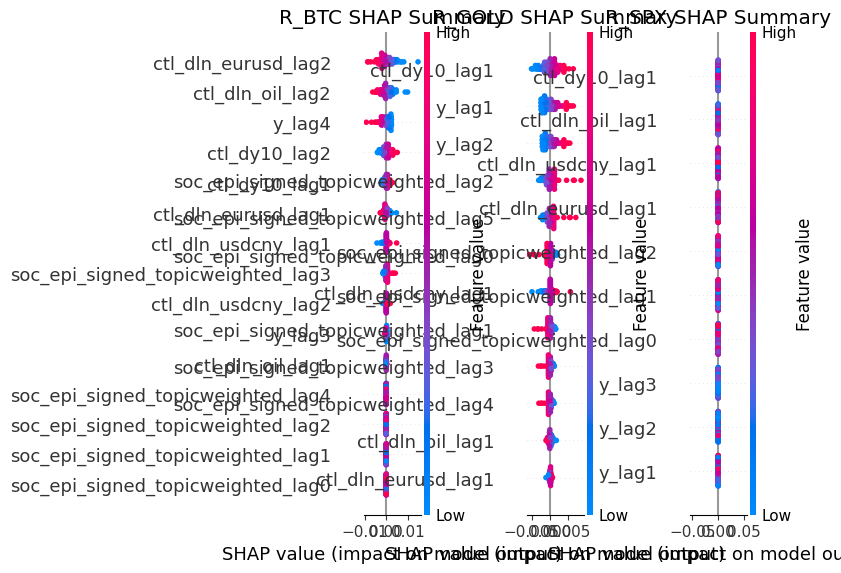

In [16]:
# SHAP Summary Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for idx, target in enumerate(TARGET_COLS):
    plt.sca(axes[idx])
    shap.summary_plot(
        shap_results[target]['shap_values'],
        shap_results[target]['X_design'],
        feature_names=shap_results[target]['feature_names'],
        max_display=15,
        show=False
    )
    axes[idx].set_title(f'{target.upper()} SHAP Summary')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_emotion_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Cumulative Returns Analysis

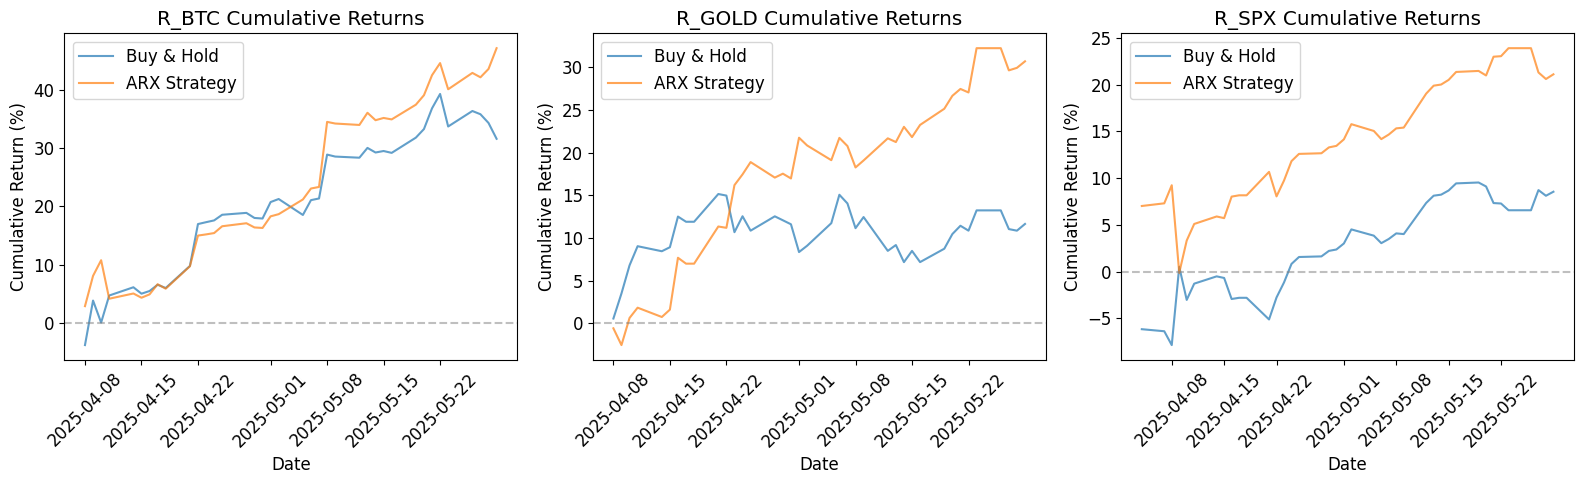


Cumulative Returns Summary:
  r_btc:
    Buy & Hold: 31.57%
    Strategy:   47.12%
  r_gold:
    Buy & Hold: 11.66%
    Strategy:   30.72%
  r_spx:
    Buy & Hold: 8.55%
    Strategy:   21.11%

Trading Metrics Summary:

R_BTC:
  Sharpe Ratio:     7.047
  Sortino Ratio:    9.297
  Calmar Ratio:     44.271
  Max Drawdown:     -5.96%
  Win Rate:         71.1%
  Profit Factor:    4.01

R_GOLD:
  Sharpe Ratio:     5.907
  Sortino Ratio:    17.865
  Calmar Ratio:     63.936
  Max Drawdown:     -2.86%
  Win Rate:         55.3%
  Profit Factor:    2.83

R_SPX:
  Sharpe Ratio:     3.739
  Sortino Ratio:    2.853
  Calmar Ratio:     14.765
  Max Drawdown:     -8.58%
  Win Rate:         75.0%
  Profit Factor:    2.29


In [17]:
# Compute momentum-based trading strategy with volatility scaling
from modules.finance.evaluation.trading_metrics import (
    generate_volatility_scaled_positions,
    compute_trading_metrics
)

cumulative_returns = {}
trading_metrics_all = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, target in enumerate(TARGET_COLS):
    preds_df = oos_predictions[target]
    
    # Get asset name
    asset = target.replace('r_', '')
    
    # Get momentum signal (5-day primary) and convert to ±1
    momentum_col = f'momentum_5d_{asset}'
    if momentum_col not in df_clean.columns:
        print(f"Warning: {momentum_col} not found, using sign of predictions")
        momentum_signal = np.sign(preds_df['y_pred'].values)
    else:
        # Align momentum with prediction dates and convert to directional signal
        momentum_values = df_clean.loc[preds_df.index, momentum_col].values
        momentum_signal = np.sign(momentum_values)  # Convert to ±1
    
    # Get signed actual returns (MUST use signed column, not y_true which is absolute)
    signed_col = f'r_{asset}_signed'
    if signed_col in df_clean.columns:
        actual_signed_returns = df_clean.loc[preds_df.index, signed_col].values
    else:
        # Fallback: convert absolute returns to signed using momentum
        print(f"Warning: {signed_col} not found, reconstructing from absolute returns")
        actual_signed_returns = preds_df['y_true'].values * momentum_signal
    
    # Generate volatility-scaled positions
    # y_pred contains predicted volatility (absolute returns), use for inverse vol weighting
    predicted_volatility = preds_df['y_pred'].values
    positions = generate_volatility_scaled_positions(
        momentum_signals=momentum_signal,
        predicted_volatility=predicted_volatility,
        percentile_cap=95,
        percentile_floor=5
    )
    
    # Strategy returns (position * actual signed return)
    strategy_returns = positions * actual_signed_returns
    
    # Cumulative returns
    cum_buy_hold = np.cumprod(1 + actual_signed_returns) - 1
    cum_strategy = np.cumprod(1 + strategy_returns) - 1
    
    cumulative_returns[target] = {
        'dates': preds_df.index,
        'buy_hold': cum_buy_hold,
        'strategy': cum_strategy,
        'final_buy_hold': cum_buy_hold[-1],
        'final_strategy': cum_strategy[-1],
    }
    
    # Compute trading metrics
    trading_metrics = compute_trading_metrics(
        strategy_returns=strategy_returns,
        buy_hold_returns=actual_signed_returns
    )
    trading_metrics_all[target] = trading_metrics
    
    # Plot
    ax = axes[idx]
    ax.plot(preds_df.index, cum_buy_hold * 100, label='Buy & Hold', alpha=0.7)
    ax.plot(preds_df.index, cum_strategy * 100, label='ARX Strategy', alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{target.upper()} Cumulative Returns')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(loc='best')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_index_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nCumulative Returns Summary:")
for target, data in cumulative_returns.items():
    print(f"  {target}:")
    print(f"    Buy & Hold: {data['final_buy_hold']*100:.2f}%")
    print(f"    Strategy:   {data['final_strategy']*100:.2f}%")

print("\nTrading Metrics Summary:")
for target, metrics in trading_metrics_all.items():
    print(f"\n{target.upper()}:")
    print(f"  Sharpe Ratio:     {metrics['sharpe_ratio']:.3f}")
    print(f"  Sortino Ratio:    {metrics['sortino_ratio']:.3f}")
    print(f"  Calmar Ratio:     {metrics['calmar_ratio']:.3f}")
    print(f"  Max Drawdown:     {metrics['max_drawdown']*100:.2f}%")
    print(f"  Win Rate:         {metrics['win_rate']*100:.1f}%")
    print(f"  Profit Factor:    {metrics['profit_factor']:.2f}")

## Save Results

In [18]:
# Save metrics
metrics_output = []
for target in TARGET_COLS:
    spec = emotion_results[target]['best_lags']
    cv = emotion_results[target]
    oos = oos_metrics[target]
    cum_ret = cumulative_returns[target]
    
    metrics_output.append({
        'asset': target,
        'model': 'ARX_emotion',
        'p': spec.ar_p,
        'q_control': spec.q_controls,
        'q_ei': spec.q_ei,
        'q_epi': spec.q_epi,
        'q_epi_signed': spec.q_epi_signed,
        'q_ccd': spec.q_ccd,
        'q_intensity': spec.q_intensity,
        'q_surprise': spec.q_surprise,
        'q_split': spec.q_split,
        'cv_mae': cv['best_score_mae'],
        'cv_rmse': cv['best_score_rmse'],
        'oos_mae': oos['mae'],
        'oos_rmse': oos['rmse'],
        'oos_mape': oos['mape'],
        'cum_return_buy_hold': cum_ret['final_buy_hold'],
        'cum_return_strategy': cum_ret['final_strategy'],
    })

metrics_output_df = pd.DataFrame(metrics_output)
metrics_output_df.to_csv(OUTPUT_DIR / 'arx_emotion_metrics.csv', index=False)
print(f"Saved metrics to {OUTPUT_DIR / 'arx_emotion_metrics.csv'}")

# Save predictions
for target in TARGET_COLS:
    oos_predictions[target].to_csv(OUTPUT_DIR / f'arx_emotion_predictions_{target}.csv')
print(f"Saved predictions to {OUTPUT_DIR}")

# Save bootstrap results (bootstrap_results is now a DataFrame per target)
bootstrap_output = []
for target in TARGET_COLS:
    results_df = bootstrap_results[target].reset_index()
    for _, row in results_df.iterrows():
        bootstrap_output.append({
            'asset': target,
            'feature': row['feature'],
            'coef': row['coef'],
            'se': row.get('se', np.nan),
            'boot_mean': row.get('boot_mean', np.nan),
            'ci_lower_99': row.get('ci_lower_99', np.nan),
            'ci_upper_99': row.get('ci_upper_99', np.nan),
            'sig_99': row.get('sig_99', np.nan),
            'ci_lower_95': row.get('ci_lower_95', np.nan),
            'ci_upper_95': row.get('ci_upper_95', np.nan),
            'sig_95': row.get('sig_95', np.nan),
            'ci_lower_90': row.get('ci_lower_90', np.nan),
            'ci_upper_90': row.get('ci_upper_90', np.nan),
            'sig_90': row.get('sig_90', np.nan),
        })

bootstrap_df = pd.DataFrame(bootstrap_output)
bootstrap_df.to_csv(OUTPUT_DIR / 'arx_emotion_bootstrap.csv', index=False)
print(f"Saved bootstrap results to {OUTPUT_DIR / 'arx_emotion_bootstrap.csv'}")

# Save SHAP results summary
shap_output = []
for target in TARGET_COLS:
    for feat, val in shap_results[target]['mean_abs_shap'].items():
        shap_output.append({
            'asset': target,
            'feature': feat,
            'mean_abs_shap': val
        })

shap_df = pd.DataFrame(shap_output)
shap_df.to_csv(OUTPUT_DIR / 'arx_emotion_shap.csv', index=False)
print(f"Saved SHAP results to {OUTPUT_DIR / 'arx_emotion_shap.csv'}")

print("\n✅ All emotion-enhanced ARX results saved successfully!")

Saved metrics to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_emotion_metrics.csv
Saved predictions to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim
Saved bootstrap results to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_emotion_bootstrap.csv
Saved SHAP results to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_emotion_shap.csv

✅ All emotion-enhanced ARX results saved successfully!
